In [1]:
from py_files.setup import *
setup_notebook()

# Impulse response functions

Simulates a permanent capital income tax cut and plots the full transition path from the old to the new steady state. The notebook calls `capinc_single`, `build_output_single`, and `IRF` from the python library.

The tax cut follows geometric convergence in the net-of-tax rate,

$$
    (1-\tau_t) = (1-\tau_T) + \rho^t\left[(1-\tau_0) - (1-\tau_T)\right], \quad t = 0, 1, \ldots, T,
$$

from $(1-\tau_0) = 1$ to $(1-\tau_T) = 1.1$, mechanically mimicking a subsidy. Welfare gains are decomposed into contributions for consumption workers $(WG_C)$, investment workers $(wg_I)$, and capitalists $(wg_K)$, discounted at the world interest rate $r$.

*`1. calibration and simulation`*

*calibrate to zero SS wage premia and target labour supply elasticity $\varepsilon_{nI} = (1-s_L)\phi$*

In [2]:
# 1. calibrate
# m = CapIncModel()
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi)

# 2. pin baseline SS first
T=30; tau0=0.0; tauT=-0.1; rho=0.80; tail=25; tau_ss=0.0 
ss0 = m.solve_steady_state(tau=tau0)


 Calibrate household: zero wage premia + target eps_nI 
targets    prem=0, prem=0, eps=0.8
------------------------------------------------------------
old        mu=0.26   =>
           log(wI/wC)=-9.34e-03

old        phi=0.75 =>
           eps=0.556
------------------------------------------------------------
new        mu=0.2569   =>
           log(wI/wC)=-5.23e-14

new        phi=1.0092 =>
           eps=0.750



*run the tax cut process and compute welfare decomposition — parameters $(\tau_0, \tau_T, \rho)$ set above*

In [3]:
# # 2. params and sim
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)
# net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(
#     T=T, tail=tail,
# )

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)

res_elas = build_output_single.inc_elas(m, sim, tau=tau_ss) 


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers     27.4%
Investment workers      48.0%
Capitalists             24.6%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.56
epsS_SR        0.13
epsD           1.44

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.56
quant_elas     0.87
wealth_ela     1.42



*`2. impulse response functions`*

*three paths: (i) permanent shock from $\tau_0$ to $\tau_T$, (ii) baseline SS held at $\tau_0$, (iii) new SS held at $\tau_T$*

In [4]:
# 1. initiate
gamma  = 0.8
T_solve = T + tail

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)
ss1 = m.solve_steady_state(tau=tauT)

*solve transitions*

In [5]:
# 1.paths
_, tau_t1_long, _, _ = shocks.perm_tc(T=T, tail=tail, 
                                      tau0=tau0, tauT=tauT, rho=rho)
# net_long, tau_t1_long, dlog_net_long, tauT = shocks.temp_tc(
#     T=T, tail=tail,
# )


tau_t2_long = np.full_like(tau_t1_long, tau0)
tau_t3_long = np.full_like(tau_t1_long, tauT)

# 3. intial guesses
qg0 = np.full(T_solve + 1, ss0["q"])
qg1 = np.full(T_solve + 1, ss1["q"])

# 4. simulations
# 4.1 baseline ss
sim2 = m.solve_transition(tau_path=tau_t2_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tau0)

# 4.2 new ss
sim3 = m.solve_transition(tau_path=tau_t3_long, K0=ss1["K"],
                          q_guess_path=qg1, tau_terminal=tauT)

# 4.3 permanent shock
sim1 = m.solve_transition(tau_path=tau_t1_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)

h = np.arange(T + 1)

/Users/linuslindquist/micromamba/lib/python3.9/site-packages/scipy/optimize/_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


*plot — log deviations from baseline SS; welfare panels in % of SS consumption*

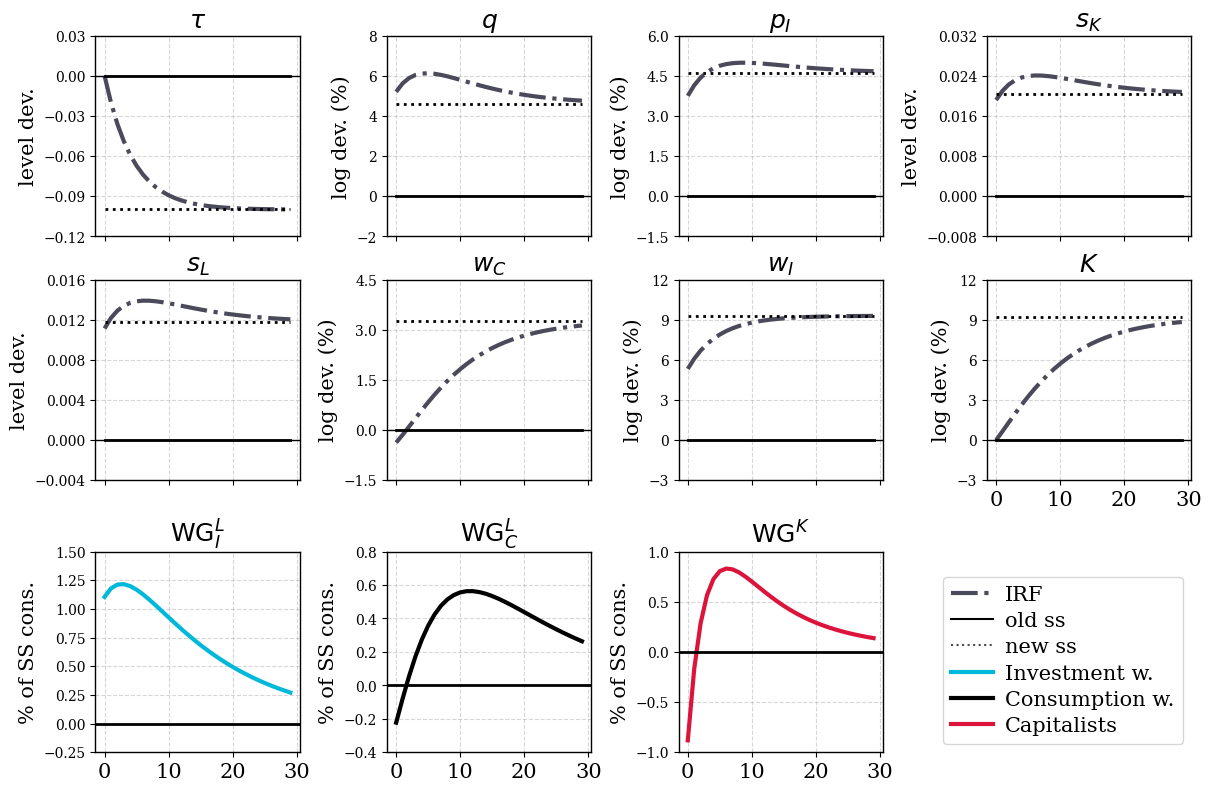

In [6]:
# from py_files.IRF import plot_irf

plot_irf(
    sim1       = sim1,
    sim2       = sim2,
    sim3       = sim3,
    sim_welfare= sim,          # the welfare dict from build_output_single.welfare_effects
    T_plot     = T,
    C_ss       = float(sim2["C"][0]),
    savepath   = "0_output/sim_lr_cs.png",
)